# Eksperimen SML - Wine Classification

**Nama:** Fathir

**Dataset:** Wine Recognition Dataset (UCI Machine Learning Repository)

## 1. Perkenalan Dataset

Wine Recognition Dataset berisi hasil analisis kimia terhadap **3 jenis wine** yang berbeda dari wilayah Italia.

- **Jumlah sampel:** 178
- **Jumlah fitur:** 13 (semua numerik/kontinu)
- **Jumlah kelas:** 3 (class_0, class_1, class_2)
- **Task:** Klasifikasi Multiclass

**Fitur-fitur:**
1. Alcohol
2. Malic acid
3. Ash
4. Alcalinity of ash
5. Magnesium
6. Total phenols
7. Flavanoids
8. Nonflavanoid phenols
9. Proanthocyanins
10. Color intensity
11. Hue
12. OD280/OD315 of diluted wines
13. Proline

## 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil di-import!')

Library berhasil di-import!


## 3. Memuat Dataset

In [2]:
# Load Wine dataset dari sklearn
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Mapping target ke nama kelas
target_names = {0: 'class_0', 1: 'class_1', 2: 'class_2'}
df['target_name'] = df['target'].map(target_names)

print(f'Dataset shape: {df.shape}')
print(f'\nTarget distribution:')
print(df['target_name'].value_counts())

# Simpan data mentah
raw_dir = os.path.join('..', 'wine_raw')
os.makedirs(raw_dir, exist_ok=True)
df.to_csv(os.path.join(raw_dir, 'wine_raw.csv'), index=False)
print(f'\nData mentah disimpan ke: {raw_dir}/wine_raw.csv')

df.head(10)

Dataset shape: (178, 15)

Target distribution:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

Data mentah disimpan ke: ..\wine_raw/wine_raw.csv


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0,class_0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0,class_0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0,class_0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0,class_0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0,class_0


## 4. Exploratory Data Analysis (EDA)

In [3]:
# 4.1 Statistik Deskriptif
print('=== Statistik Deskriptif ===')
df.describe()

=== Statistik Deskriptif ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [4]:
# 4.2 Cek Missing Values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values ===
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0
dtype: int64

Total missing values: 0


In [5]:
# 4.3 Cek Duplikat
duplicates = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplicates}')

Jumlah data duplikat: 0


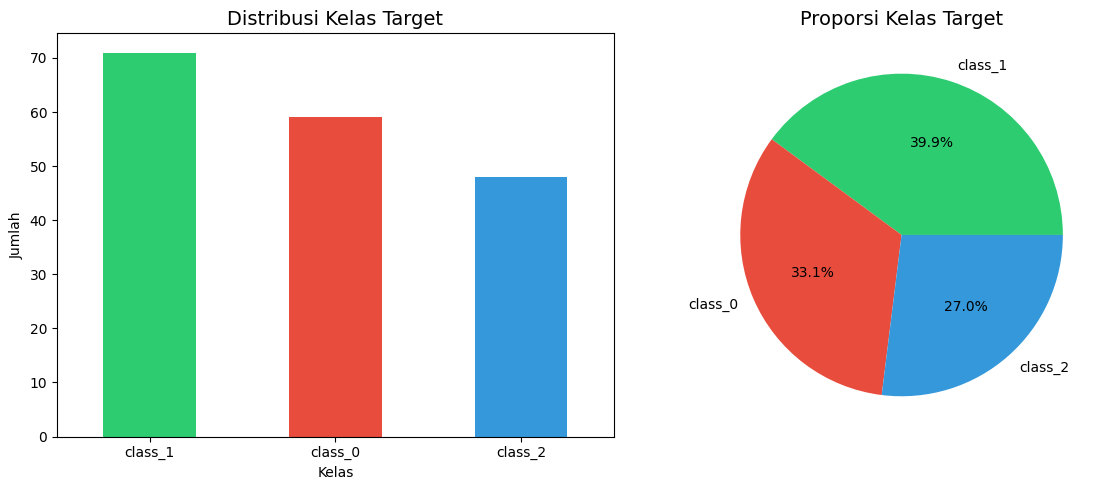

In [6]:
# 4.4 Distribusi Kelas Target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c', '#3498db']
df['target_name'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribusi Kelas Target', fontsize=14)
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['target_name'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors)
axes[1].set_title('Proporsi Kelas Target', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

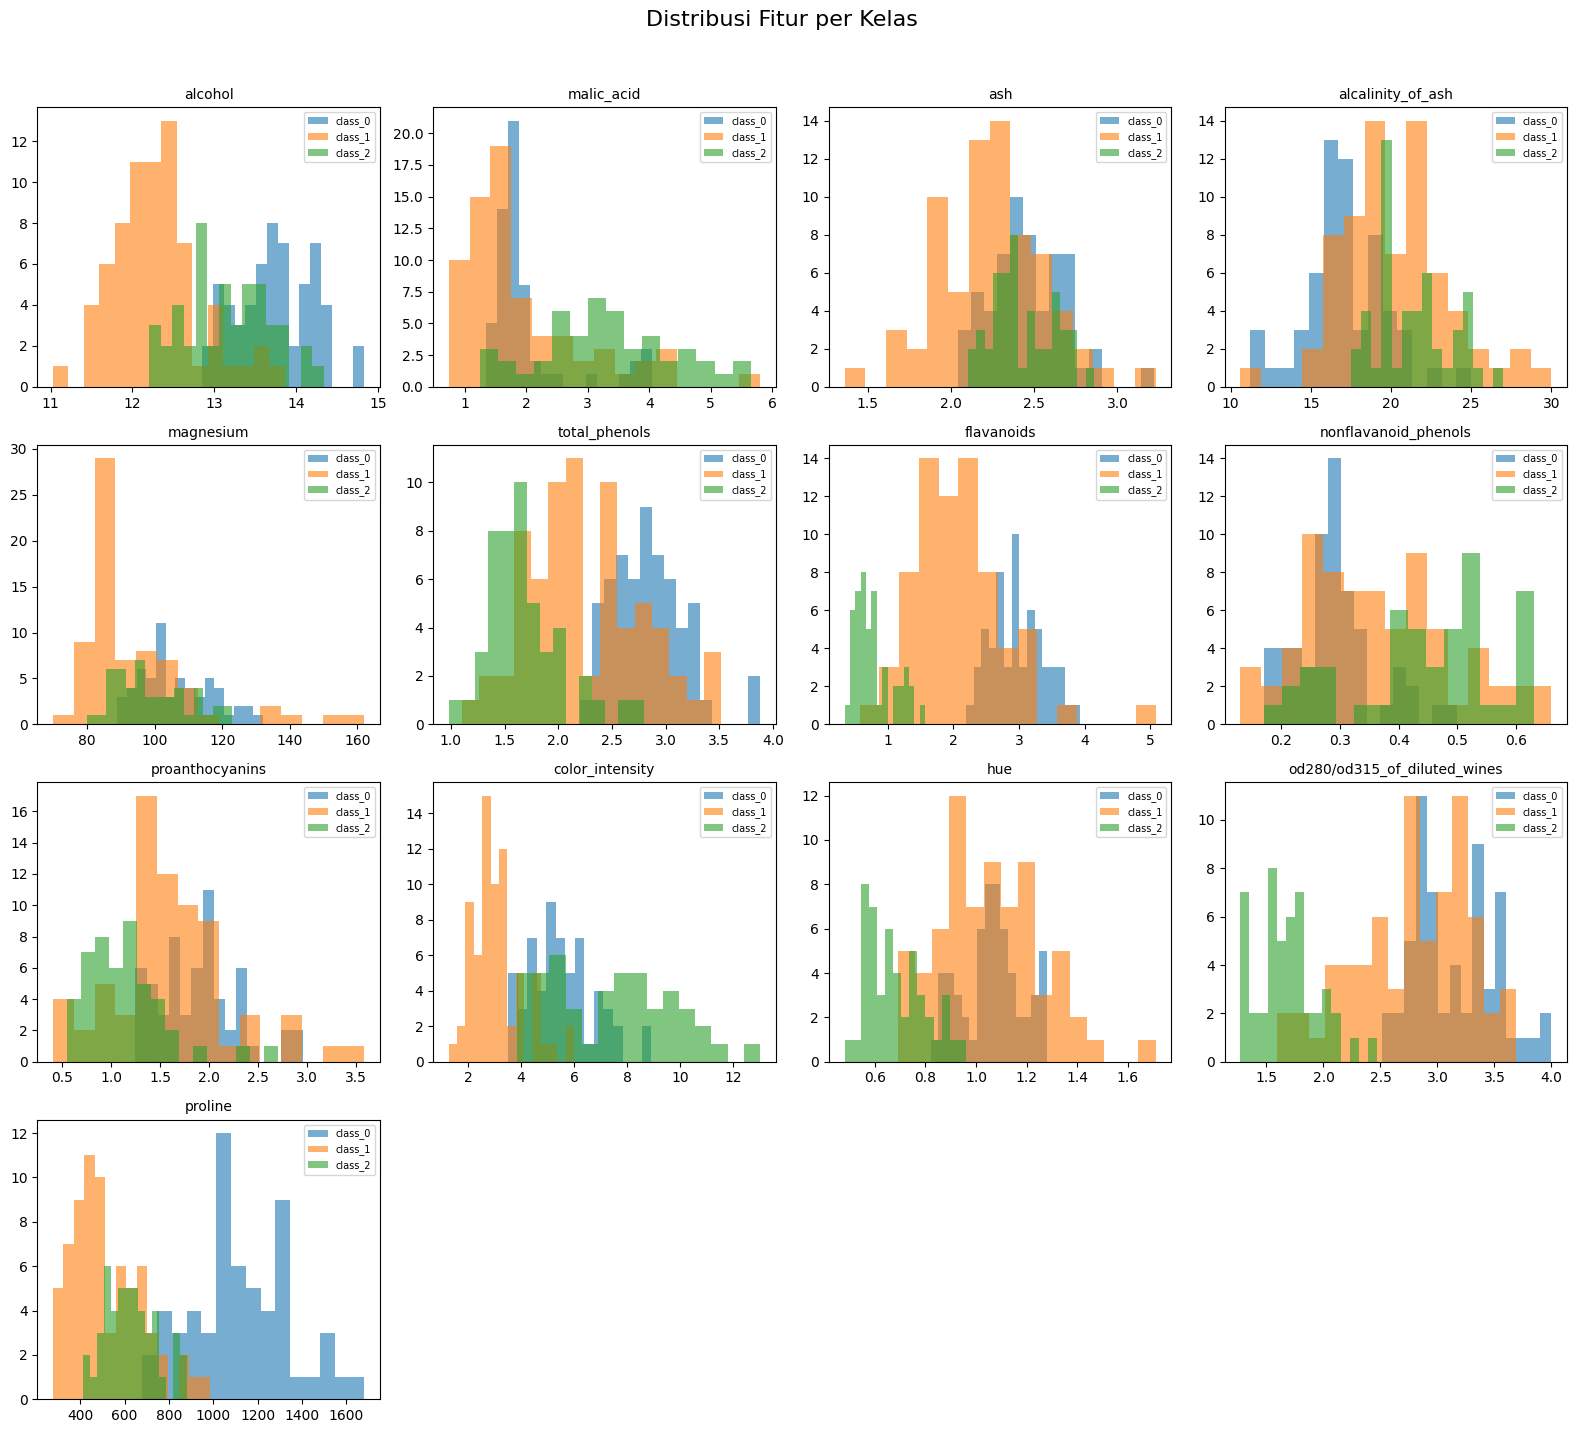

In [7]:
# 4.5 Histogram - Distribusi setiap fitur
features = wine.feature_names
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    for cls in [0, 1, 2]:
        axes[i].hist(df[df['target'] == cls][col], alpha=0.6, label=f'class_{cls}', bins=15)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

# Hide extra subplots
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribusi Fitur per Kelas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

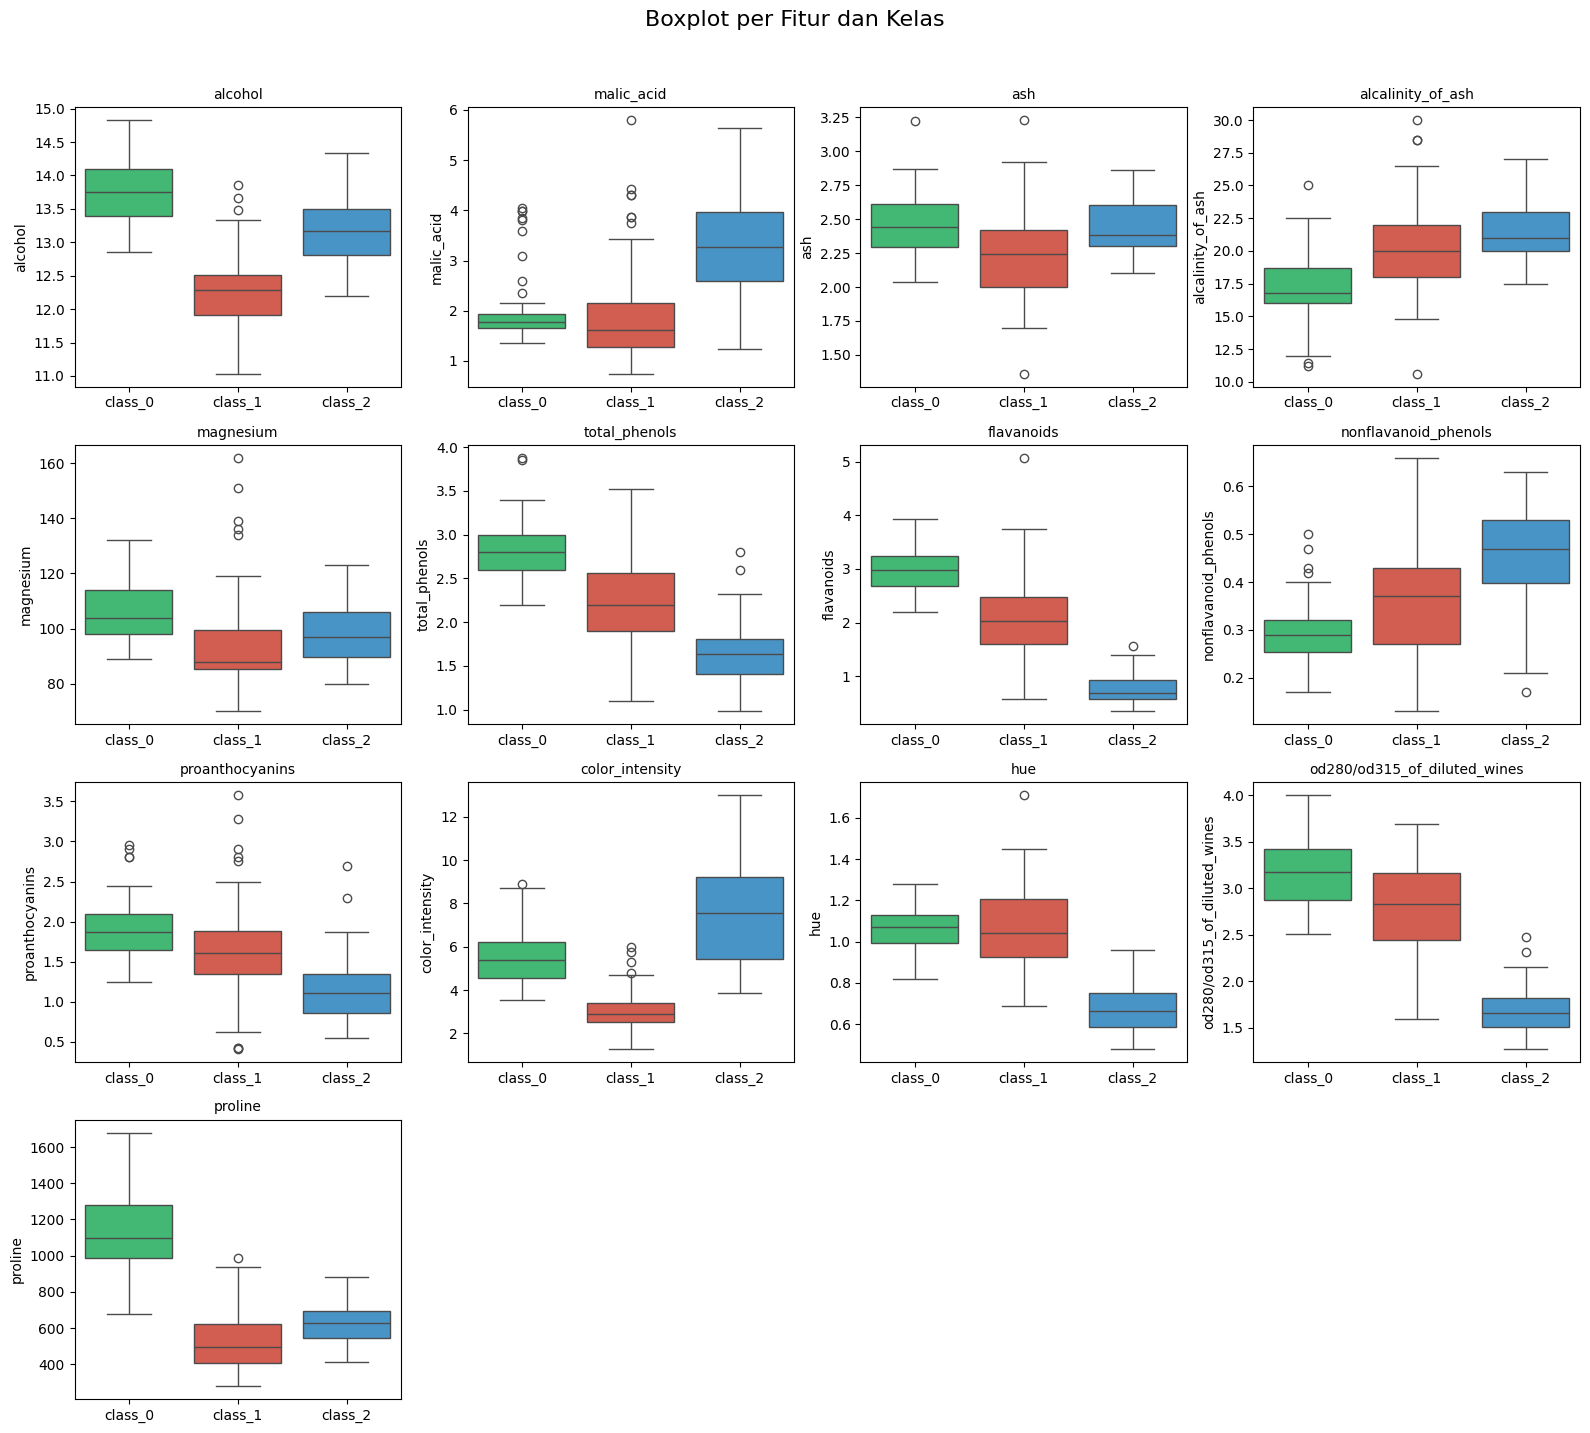

In [8]:
# 4.6 Boxplot - Deteksi Outlier
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='target_name', y=col, ax=axes[i], palette=colors)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplot per Fitur dan Kelas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

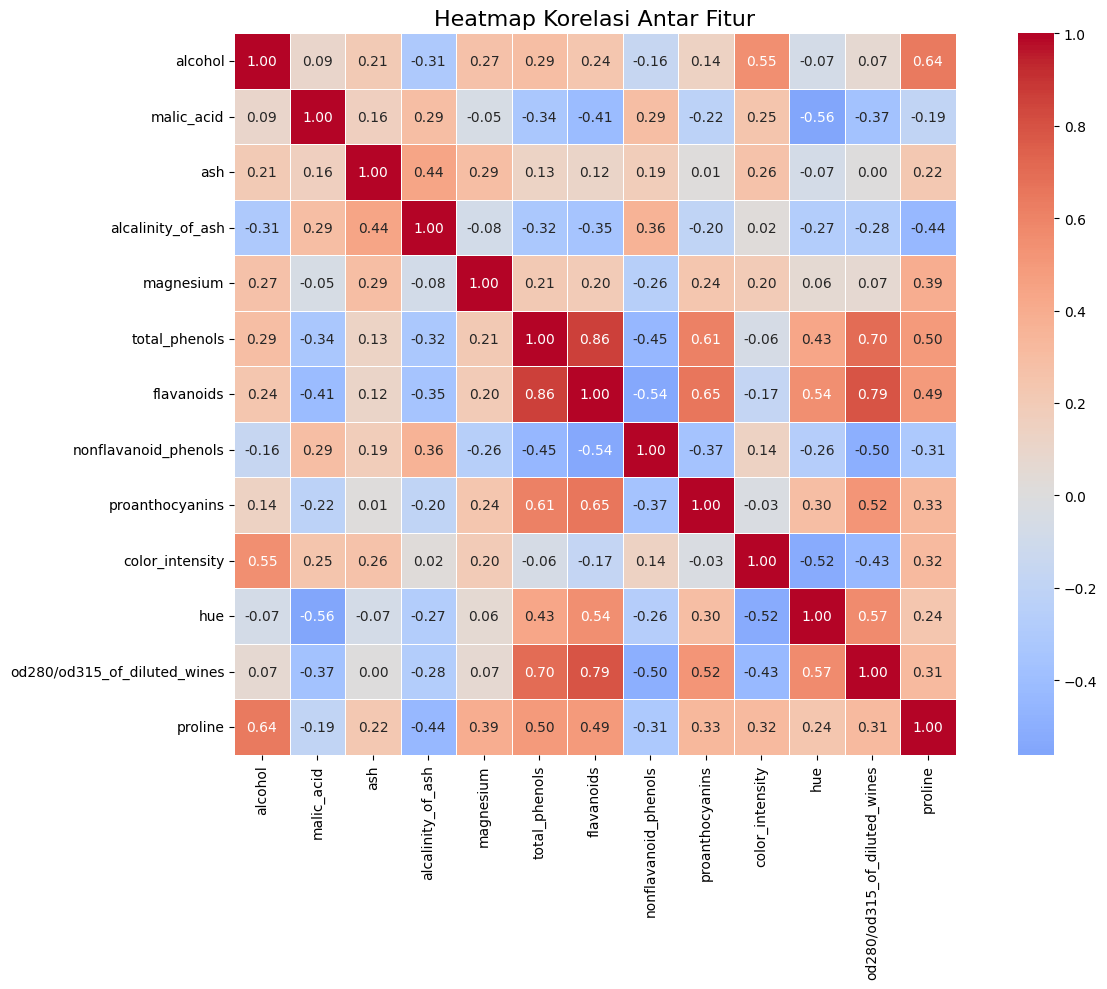

In [9]:
# 4.7 Heatmap Korelasi
plt.figure(figsize=(14, 10))
corr_matrix = df[features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=16)
plt.tight_layout()
plt.show()

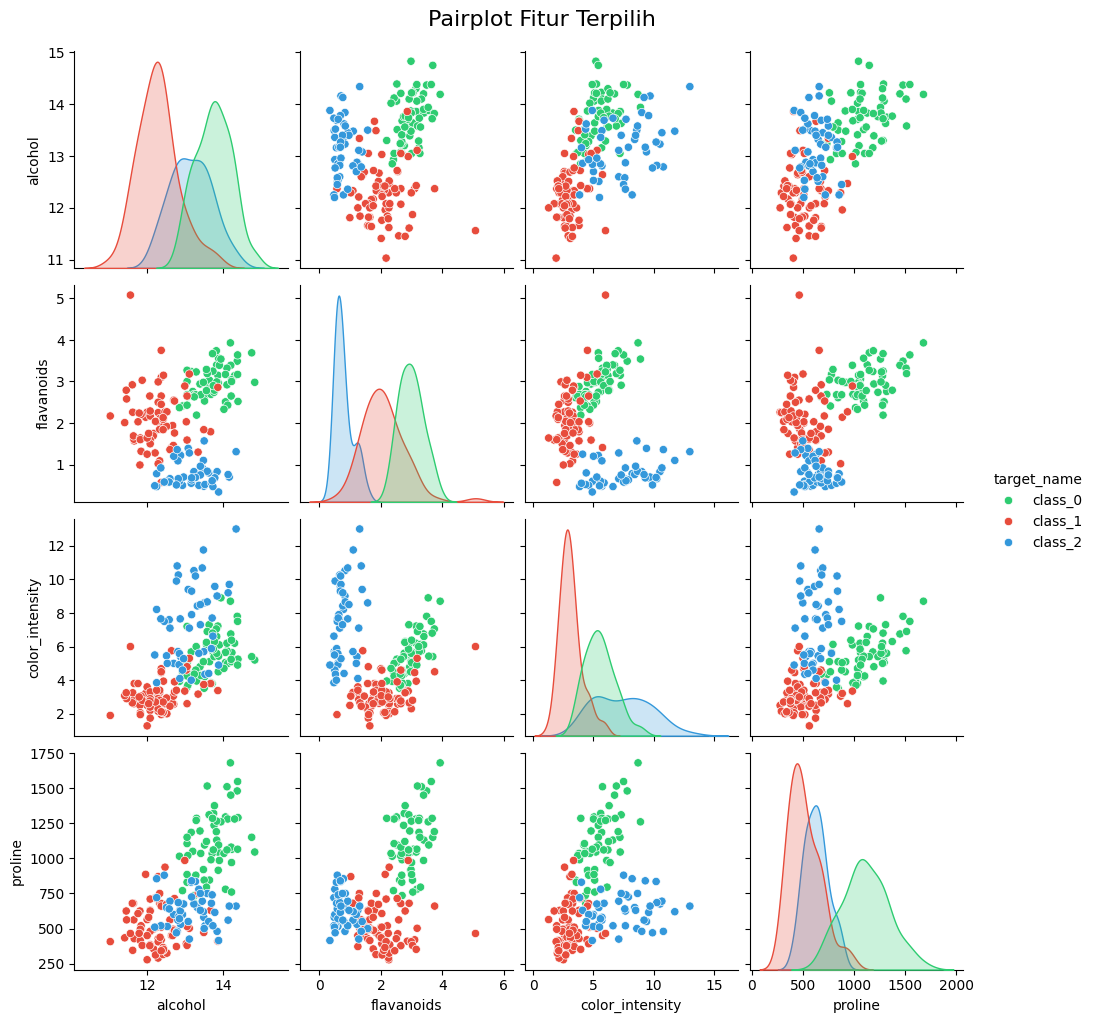

In [10]:
# 4.8 Pairplot (subset fitur paling diskriminatif)
selected_features = ['alcohol', 'flavanoids', 'color_intensity', 'proline', 'target_name']
sns.pairplot(df[selected_features], hue='target_name', palette=colors, diag_kind='kde')
plt.suptitle('Pairplot Fitur Terpilih', y=1.02, fontsize=16)
plt.show()

## 5. Preprocessing

In [11]:
# 5.1 Hapus duplikat (jika ada)
df_clean = df.drop(columns=['target_name']).copy()
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f'Data sebelum hapus duplikat: {before}')
print(f'Data sesudah hapus duplikat: {after}')
print(f'Duplikat dihapus: {before - after}')

Data sebelum hapus duplikat: 178
Data sesudah hapus duplikat: 178
Duplikat dihapus: 0


In [12]:
# 5.2 Handle missing values (tidak ada, tapi tetap dicek)
print(f'Missing values: {df_clean.isnull().sum().sum()}')
# Jika ada, akan diisi dengan median
if df_clean.isnull().sum().sum() > 0:
    df_clean = df_clean.fillna(df_clean.median())
    print('Missing values telah diisi dengan median')
else:
    print('Tidak ada missing values - data bersih')

Missing values: 0
Tidak ada missing values - data bersih


In [13]:
# 5.3 Feature Scaling dengan StandardScaler
feature_cols = [c for c in df_clean.columns if c != 'target']
scaler = StandardScaler()
df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])

print('StandardScaler berhasil diterapkan')
print(f'\nStatistik setelah scaling:')
df_clean[feature_cols].describe().round(4)

StandardScaler berhasil diterapkan

Statistik setelah scaling:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000
mean,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000
std,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028
min,-2.4342,-1.4330,-3.6792,-2.6710,-2.0883,-2.1072,-1.6960,-1.8682,-2.0690,-1.6343,-2.0947,-1.8951,-1.4932
25%,-0.7882,-0.6587,-0.5721,-0.6891,-0.8244,-0.8855,-0.8275,-0.7401,-0.5973,-0.7951,-0.7676,-0.9522,-0.7846
50%,0.0610,-0.4231,-0.0238,0.0015,-0.1223,0.0960,0.1061,-0.1761,-0.0629,-0.1592,0.0331,0.2377,-0.2337
75%,0.8361,0.6698,0.6981,0.6021,0.5096,0.8090,0.8491,0.6095,0.6292,0.4940,0.7132,0.7886,0.7582
max,2.2598,3.1092,3.1563,3.1545,4.3714,2.5395,3.0628,2.4024,3.4851,3.4354,3.3017,1.9609,2.9715


In [14]:
# 5.4 Train-Test Split
X = df_clean.drop(columns=['target'])
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total data: {len(df_clean)}')
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nDistribusi target di training set:')
print(y_train.value_counts().sort_index())
print(f'\nDistribusi target di test set:')
print(y_test.value_counts().sort_index())

Total data: 178
Training set: (142, 13)
Test set: (36, 13)

Distribusi target di training set:
target
0    47
1    57
2    38
Name: count, dtype: int64

Distribusi target di test set:
target
0    12
1    14
2    10
Name: count, dtype: int64


In [15]:
# 5.5 Simpan data preprocessed
prep_dir = os.path.join('.', 'wine_preprocessing')
os.makedirs(prep_dir, exist_ok=True)

output_path = os.path.join(prep_dir, 'wine_preprocessed.csv')
df_clean.to_csv(output_path, index=False)

print(f'Data preprocessed disimpan ke: {output_path}')
print(f'Shape: {df_clean.shape}')
print(f'\nPreview data preprocessed:')
df_clean.head()

Data preprocessed disimpan ke: .\wine_preprocessing\wine_preprocessed.csv
Shape: (178, 14)

Preview data preprocessed:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009,0
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242,0
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148,0
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574,0
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874,0


## Kesimpulan

1. **Dataset Wine** memiliki 178 sampel dengan 13 fitur numerik dan 3 kelas target
2. **Tidak ada missing values** dan **tidak ada data duplikat**
3. **EDA** menunjukkan beberapa fitur (alcohol, flavanoids, proline) memiliki daya pisah yang baik antar kelas
4. **Preprocessing** meliputi: pengecekan duplikat, pengecekan missing values, StandardScaler, dan train-test split (80:20)
5. Data siap digunakan untuk tahap modelling